# Creating ANN to Predict Output of Function sin(x)

### Creating the data

In [2]:
import pandas as pd
import random
from math import sin
from matplotlib import pyplot as plt

In [3]:
someList = []
random.seed(1)

for i in range(1000):
    x = random.random() * 4
    y = sin(x)
    someList.append([x, y])

In [4]:
df = pd.DataFrame(someList)
df.columns = ['x', 'y']
df.head()

,x,y
0,0.537457,0.511953
1,3.389735,-0.245604
2,3.055098,0.086386
3,1.020276,0.852252
4,1.981740,0.916744


### Getting and plotting the data

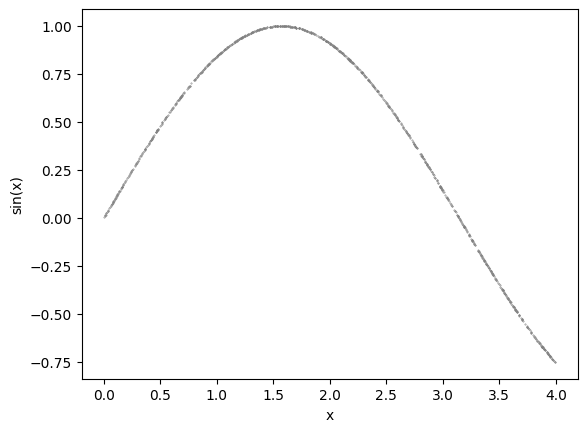

In [5]:
plt.scatter(df['x'], df['y'], color = 'grey', marker = '.', s = 0.5)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

### Data set split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df['x'], df['y'], train_size = 0.8, shuffle = True)

### Creating a network model

In [8]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [9]:
model = Sequential()
model.add(Dense(4, input_dim = 1, activation = 'tanh'))
model.add(Dense(5, activation = 'tanh'))
model.add(Dense(1, activation = 'linear'))

In [10]:
model.compile(loss = 'mse', optimizer = 'adam')

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4)                 8         
                                                                 
 dense_1 (Dense)             (None, 5)                 25        
                                                                 
 dense_2 (Dense)             (None, 1)                 6         
                                                                 
Total params: 39 (156.00 Byte)
Trainable params: 39 (156.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
early_stop = EarlyStopping(monitor = 'loss', patience = 2, verbose = 1)

### Fit the model

In [14]:
model.fit(X_train, y_train, epochs = 10, batch_size = 1, callbacks = [early_stop])

Epoch 1/10
800/800 [==============================] - 2s 2ms/step - loss: 2.6426e-04
Epoch 2/10
800/800 [==============================] - 2s 2ms/step - loss: 2.0240e-04
Epoch 3/10
800/800 [==============================] - 2s 3ms/step - loss: 1.9177e-04
Epoch 4/10
800/800 [==============================] - 2s 3ms/step - loss: 1.7243e-04
Epoch 5/10
800/800 [==============================] - 2s 3ms/step - loss: 1.7616e-04
Epoch 6/10
800/800 [==============================] - 2s 3ms/step - loss: 1.4709e-04
Epoch 7/10
800/800 [==============================] - 2s 2ms/step - loss: 1.5483e-04
Epoch 8/10
800/800 [==============================] - 2s 2ms/step - loss: 1.5229e-04
Epoch 8: early stopping


### Make predictions

In [15]:
y_pred = model.predict(X_test)

7/7 [==============================] - 0s 3ms/step


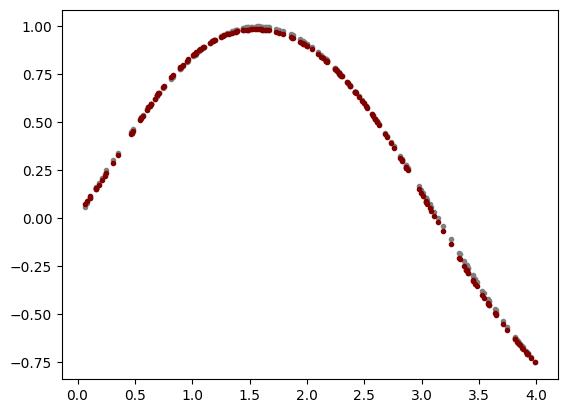

In [16]:
plt.scatter(X_test, y_test, marker = '.', color = 'grey')
plt.scatter(X_test, y_pred, marker = '.', color = 'maroon')
plt.show()